# Wildfire Impact Analysis Using Satellite Imagery

By Aycha Tammour

Wildfires affect ecosystems, infrastructure, air quality, and local economies. Satellite imagery provides a scalable way to assess impacts in regions where field surveys may be expensive, dangerous, or impossible. This workflow demonstrates how open Earth observation data can be used to rapidly estimate wildfire damage. I use a wildfire event in Northwest Syria as a case study, where I examine changes in vegetation health and moisture content before and after the fire. 

This workflow uses a fully Python-based pipeline leveraging STAC for cloud-native data access, xarray/Dask for scalable processing, and scikit-learn for validation.

I use data from:
- the Sentinel-2 satellite, which provides high-resolution multispectral imagery suitable for vegetation analysis
- NASA's FIRMS (Fire Information for Resource Management System) to identify fire dates
- the Copernicus Emergency Management Service (EMS) to validate the fire extent

Many of the techniques demonstrated here for extracting data and analyzing environmental change can be applied to other regions.


The workflow is implemented in Python using the following libraries

| Package | Purpose |
|---------|---------|
| `xarray` | Handling multi-dimensional arrays and datasets |
| `rasterio` | Reading and writing geospatial raster data |
|`pystac`, `odc-stac` | Accessing and working with SpatioTemporal Asset Catalogs (STAC) |
| `Dask` | Parallel computing and handling large datasets |
| `numpy` | Numerical operations on arrays |
|`scikit-learn`| Classification metrics |
| `geopandas` | Working with geospatial vector data |
|`Shapely`| Manipulating and analyzing geometric objects |
| `matplotlib`, `Seaborn` | Data visualization |
| `folium` | Interactive maps |


Throught this workflow, imports are introduced where first used for clarity and to avoid overwhelming the reader with a long list of imports at the beginning. The workflow is structured in a way that allows readers to follow along step by step, with explanations provided for each major section of code.

I put links to the code used in this workflow in the relevant sections, but you can also find the full code in this [GitHub repository](https://github.com/astroAycha/wildfire_impact_analysis/tree/main).

# The Study Area

Our study area is a mountainous region in Northwest Syria centered around Qastal Maaf, a small town near Latakia in Syria, which has been impacted by a devastating wildfire in the summer of 2025.
Let's start by defining the area of interest (AOI). We will use this AOI to query and extract satellite imagery for our analysis.

In [137]:
from shapely.geometry import box
import geopandas as gpd
from pyproj import Transformer


extent = [35.90777443208602, 35.787983030464474, 35.996223199478145, 35.8600167101125]

# AOI into a GeoDataFrame in WGS84
aoi_gdf = gpd.GeoDataFrame(
    geometry=[box(*extent)],
    crs="EPSG:4326"
)

# calculate the area of the AOI in km²
aoi_utm = aoi_gdf.to_crs("EPSG:32637")

area_km2 = aoi_utm.area.iloc[0] / 1e6
print(f"AOI area: {area_km2:,.3f} km²")

AOI area: 63.949 km²


## Wildfire Event Timing

As I mentioned earlier, the wildfire event occurred in the summer of 2025. To find out when exactly it happened, we can use NASA's Fire Information for Resource Management System (FIRMS) to check the specific dates on which FIRMS detected active fires. FIRMS provides global near real-time (NRT) and historical active fire data from MODIS and VIIRS instruments. By accessing the FIRMS data for our AOI, we can identify the date of the fire event and use that information to analyze the satellite imagery before and after the fire.

### Fetching Fire Data from FIRMS

To use the [FIRMS API](https://firms.modaps.eosdis.nasa.gov/api/), we need a `MAP_KEY`, which can be easily obtained from the FIRMS website. Once we have this access key, we can make API requests to retrieve active fire data for the specific location and time period of interest. It is also possible to download the data directly using the web interface on the [FIRMS website](https://firms.modaps.eosdis.nasa.gov/download/) in various formats (CSV, shapefiles, or json), which can then be processed in Python for further analysis.

I went with the option of downloading the data using the API, which allows for more efficient and automated data retrieval.

In order to get the data, we first need to build the API request URL with the appropriate parameters which include:
- `MAP_KEY`: Your FIRMS API access key. Save this in your `.env` file for security.
- `source`: The satellite data source (e.g., 'MODIS_NRT' or 'VIIRS_NOAA20_SP').
- `bbox`: The bounding box coordinates for the area of interest (AOI)
- `start`: The start date for the data retrieval (e.g., '2025-06-01')
- `end`: The end date for the data retrieval (e.g., '2025-08-31')
- `day range`: The number of days to look back from the end date (e.g., 3 days)


We then construct the API request URL with the appropriate parameters and use the `requests` library to make the API call. Here I will just use the `pandas` library to read the data directly from the API endpoint, which is a convenient way to handle the CSV data returned by FIRMS.

In [5]:
import os
import dotenv
import pandas as pd
import datetime

dotenv.load_dotenv()

base_url = "https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
map_key = os.getenv("MAP_KEY") # read the API key from the .env file
src = "VIIRS_SNPP_SP" # for example
bbox_str = ",".join(map(str, extent)) # Convert list to comma-separated string
day_range = "5" # FIRMS has a 5-day limit per request
start_date = "2025-07-09"

url = f"{base_url}{map_key}/{src}/{bbox_str}/{day_range}/{start_date}"

df = pd.read_csv(url)
print(df.shape)
print(f"Data is available for the dates: {df['acq_date'].min()} -> {df['acq_date'].max()}")
df.head()

(43, 15)
Data is available for the dates: 2025-07-09 -> 2025-07-11


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,35.85179,35.94963,353.35,0.43,0.38,2025-07-09,1025,N,VIIRS,n,2,311.93,27.60,D,0
1,35.85438,35.94379,343.68,0.43,0.38,2025-07-09,1025,N,VIIRS,n,2,311.92,48.34,D,0
2,35.85523,35.94857,367.00,0.43,0.38,2025-07-09,1025,N,VIIRS,l,2,329.77,48.34,D,0
3,35.85870,35.94763,367.00,0.43,0.38,2025-07-09,1025,N,VIIRS,h,2,309.29,48.34,D,0
4,35.85207,35.96052,346.62,0.34,0.56,2025-07-09,2246,N,VIIRS,n,2,292.79,2.84,N,0


FIRMS provide global active fire data with varying spatial and temporal resolutions. Their Near Real-Time (NRT) data is available within a few hours of satellite overpass, while their historical data goes back several years.

For this exercise, we will use three sources from the FIRMS data: `VIIRS_SNPP_SP`, `VIIRS_NOAA20_SP`, and `MODIS_SP` (SP here stands for Standard Processing). These sources provide historical fire detections from the VIIRS instruments on the Suomi NPP and NOAA-20 satellites, and the MODIS instrument on the Terra and Aqua satellites, respectively. Both VIIRS instruments are similar in design and their spatial resolution is 375 m with around 50 minutes offset between their equatorial overpasses. While FIRMS's active fire detections are lower spatial resolution than Sentinel-2, they still provide thermal anomaly information that can be used to identify the timing and location of fire events.

Since we know the fire took place in the summer of 2025, we can specify a date range around that time to retrieve the fire data. For example, we can look at a date range from April 1st, 2025, to September 1st, 2025, to capture the fire event and its immediate aftermath.

The code to fetch the FIRMS data for our AOI and specified date range is on [GitHub](https://github.com/astroAycha/wildfire_impact_analysis/blob/main/fetch_firms.py).

In [6]:
from fetch_firms import fetch_firms

df = fetch_firms(
    source=["VIIRS_SNPP_SP", "VIIRS_NOAA20_SP", "MODIS_SP"], # the FIRMS data sources to query
    bbox=extent, # the bounding box for our area of interest
    start_date="2025-04-01", # the start date for the data query
    end_date="2025-09-01" # the end date for the data query
)

Fetching FIRMS data from 2025-04-01 to 2025-09-01 for bbox: 35.90777443208602,35.787983030464474,35.996223199478145,35.8600167101125
[VIIRS_SNPP_SP] 2025-06-05 — 2 rows
[VIIRS_NOAA20_SP] 2025-06-05 — 2 rows
[MODIS_SP] 2025-06-05 — 1 rows
[VIIRS_SNPP_SP] 2025-06-30 — 82 rows
[VIIRS_NOAA20_SP] 2025-06-30 — 88 rows
[MODIS_SP] 2025-06-30 — 36 rows
[VIIRS_SNPP_SP] 2025-07-05 — 50 rows
[VIIRS_NOAA20_SP] 2025-07-05 — 150 rows
[MODIS_SP] 2025-07-05 — 68 rows
[VIIRS_SNPP_SP] 2025-07-10 — 32 rows
[VIIRS_NOAA20_SP] 2025-07-10 — 14 rows
[MODIS_SP] 2025-07-10 — 10 rows


Let's have a look at the FIRMS data to see the specific dates of the fire event in the Qastal Maaf area:

In [7]:
print(f">>> Found {df.shape[0]} unique fire events in the dataset")
print(f">>> Date range: {df['acq_date'].min()} to {df['acq_date'].max()}")

df.head(n=2)

>>> Found 535 unique fire events in the dataset
>>> Date range: 2025-06-05 to 2025-07-12


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,brightness,bright_t31
0,35.78967,35.9151,367.00,0.4,0.45,2025-06-05,1103,N,VIIRS,l,2.0,330.46,110.70,D,0,NaN,NaN
1,35.78950,35.9123,345.83,0.4,0.37,2025-06-06,1044,N,VIIRS,n,2.0,315.71,4.21,D,0,NaN,NaN


A few things to note about the FIRMS data:
- The data is provided in CSV format, which can be easily read into a pandas DataFrame for analysis.
- Each row in the FIRMS data represents a fire detection from a satellite overpass, with columns for the acquisition date and time of the detection, latitude and longitude of the fire, confidence level, and other relevant information.
- The `confidence` column indicates the confidence level of the fire detection and is given here as `l` for low, `n` for nominal, and `h` for high confidence. This can be useful for filtering the data to focus on more reliable detections.
- an important quantity in the FIRMS data is the `frp` (Fire Radiative Power), which is a measure of the energy released by the fire and can be used to estimate the intensity of the fire event.

Let's check how many observations per day the data contains and the average fire radiative power (frp) for each day:

In [8]:
(df.groupby('acq_date')['frp']
 .agg(['count', 'mean'])
 .rename(columns={'count': 'Observations', 'mean': 'Avg FRP'})
 .style.background_gradient(cmap='YlOrRd', subset=['Avg FRP'])
 )

,Observations,Avg FRP
acq_date,,
2025-06-05,4,47.785000
2025-06-06,1,4.210000
2025-07-03,47,22.129149
2025-07-04,159,130.213648
2025-07-05,141,102.065603
2025-07-06,39,22.209744
2025-07-07,36,84.850000
2025-07-08,23,38.962174
2025-07-09,29,30.350690


It appears based on the average `frp` per day that there was a flareup in the first week of June 2025 that was detected on the 5th and 6th of June but later seems to have dissipated, and the major fire event took place mainly in July starting on July 3rd and went on up until the 12th.

Let's plot the July `frp` values. The script to make the plot can be found on [GitHub](https://github.com/astroAycha/wildfire_impact_analysis/blob/d8f132299d620b1dc15b5ef03463e87c1f25c4af/plotting.py#L12)

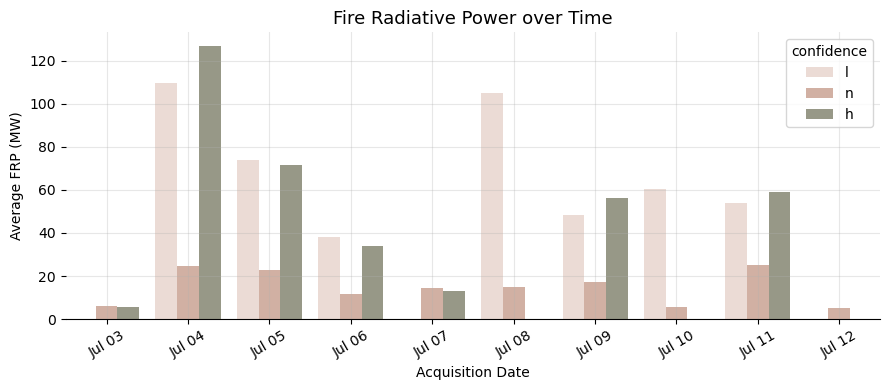

In [9]:
from plotting import plot_firms_frp

plot_firms_frp(df)

We can now plot our AOI and the fire detections from FIRMS:

In [11]:
import folium

m = folium.Map(location=[35.85, 35.95],
               zoom_start=12)

# Add basemap
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri",
    name="Esri World Imagery",
    overlay=False,
    control=True
).add_to(m)

folium.GeoJson(aoi_gdf,
                   style_function=lambda x: {
        "color": "#24B1B1",
        "fillOpacity": 0.05,
        "weight": 2
    }).add_to(m)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color="#ED725D",
        fill=False,
        fill_opacity=0.9,
        popup=folium.Popup(
            f"<b>Date:</b> {row['acq_date']}<br>"
            f"<b>FRP:</b> {row['frp']} MW<br>",
            max_width=200
        )
    ).add_to(m)

m

<!-- ## Data Acquisition -->

Now, we need to acquire the satellite imagery for our AOI and time period of interest. We will use the Sentinel-2 data, which provides high resolution multispectral imagery that can be used to calculate various spectral indices for analyzing vegetation health and moisture content. There are multiple ways to access Sentinel-2 data, including using the Copernicus Open Access Hub, Google Earth Engine, or using STAC APIs. For this walkthrough, I will demonstrate how to use the `pystac` library to access Sentinel-2 data through a STAC API. This approach allows for efficient querying and retrieval of satellite imagery based on our AOI and time period, and it can be easily automated for reproducibility.

The workflow is applied to an AOI in Latakia, Syria, but the overall approach can be adapted to other regions and time periods as needed. The key steps include:
1. Defining the AOI and time period for analysis
2. Querying and retrieving satellite imagery using the STAC API
3. Processing the imagery to mask clouds and calculate spectral indices

The full `BuildS2TimeSeries` class is available on [GitHub](https://github.com/astroAycha/wildfire_impact_analysis/blob/main/build_s2_timeseries.py), but let's walk through the three core methods that do the heavy lifting.

### 1 - Searching and Loading Data via STAC

The STAC search is straightforward. We want to search the Sentinel-2 L2A collection `sentinel-2-l2a` (which is hosted on AWS) for items that intersect the AOI and match the date range and cloud cover criteria.

We pass the 
- Collection name,
- bounding box,
- date range, 
- and a cloud cover pre-filter to avoid loading obviously unusable scenes

In [12]:
import pystac_client

collection = "sentinel-2-l2a"
start_date = "2023-01-01" # go back a few years to ensure we have pre-fire imagery for comparison
end_date = "2026-05-18"

# Open the STAC API client 
# Note: you can use any STAC API that has the data you want to search for.
#  Here we use the Earth Search API, which is a public STAC API that provides 
# access to a variety of satellite imagery and other geospatial data.
api_url = "https://earth-search.aws.element84.com/v1"
client = pystac_client.Client.open(api_url)

search = client.search(
    collections=collection,
    datetime=f"{start_date}/{end_date}", # search for items between start_date and end_date
    bbox=extent,
    query={"eo:cloud_cover": {"lt": 20}}, # filter for items with less than 20% cloud cover
)

item_collection = search.item_collection()

print(f"Found {len(item_collection.items)} items that match the criteria.")

Found 263 items that match the criteria.


It is worth noting that in addition to the `cloud_cover < 20` filter which is a scene-level pre-filter (i.e., it removes entire acquisitions where more than 20% of the scene is cloudy), the final script we will use also applies a pixel-level SCL masking to handle the remaining cloud contamination within the kept scenes.

Next we, load the data uses `odc.stac`, which handles the conversion from STAC items to an xarray Dataset and supports chunked lazy loading via Dask:

In [13]:
# filter warnings 
# mainly to remove warnings about converting datetime to nanoseconds
import warnings
warnings.filterwarnings('ignore')

In [14]:
import odc.stac

ds = odc.stac.load(
    item_collection,
    bands=['blue', 'red', 'green', 'nir', 'swir16', 'swir22', 'scl'], # <- bands to load
    group_by="solar_day", # <- group by acquisition date
    chunks={}, # <- use Dask to load in manageable chunks
    resolution=20,
    bbox=extent
)
print("Memory (MB):", round(ds.nbytes / (1024**2), 2))

Memory (MB): 547.71


Let's have a look at the resulting Dataset. We can see that it contains 7 bands (blue, red, green, nir, swir16, swir22, and scl) and 259 time steps (i.e., 259 unique acquisition dates).

In [15]:
ds

<xarray.Dataset> Size: 574MB
Dimensions:      (y: 413, x: 413, time: 259)
Coordinates:
  * y            (y) float64 3kB 3.973e+06 3.973e+06 ... 3.965e+06 3.965e+06
  * x            (x) float64 3kB 2.205e+05 2.205e+05 ... 2.287e+05 2.288e+05
    spatial_ref  int32 4B 32637
  * time         (time) datetime64[ns] 2kB 2023-01-05T08:30:12.328000 ... 202...
Data variables:
    blue         (time, y, x) uint16 88MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>
    red          (time, y, x) uint16 88MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>
    green        (time, y, x) uint16 88MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>
    nir          (time, y, x) uint16 88MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>
    swir16       (time, y, x) uint16 88MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>
    swir22       (time, y, x) uint16 88MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>
    scl          (time, y, x) uint8 44MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>

We can pick one of the bands and have a look at what the data looks like.

In [16]:
ds.red

<xarray.DataArray 'red' (time: 259, y: 413, x: 413)> Size: 88MB
dask.array<red, shape=(259, 413, 413), dtype=uint16, chunksize=(1, 413, 413), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 3kB 3.973e+06 3.973e+06 ... 3.965e+06 3.965e+06
  * x            (x) float64 3kB 2.205e+05 2.205e+05 ... 2.287e+05 2.288e+05
    spatial_ref  int32 4B 32637
  * time         (time) datetime64[ns] 2kB 2023-01-05T08:30:12.328000 ... 202...
Attributes:
    nodata:   0

A few things to note here:
- The data is loaded as a Dask array, which allows for efficient handling of large datasets without loading everything into memory at once.
- the `data type` of the bands is `unit16`, which is the native data type for Sentinel-2 L2A products. This means that the reflectance values are stored as integers and need to be scaled by a factor of 10000 to get the actual reflectance values in the range [0, 1].

### 2 - Pre-processing the Data
Before we can do any analysis of the data, we need to apply some pre-processing steps. The SCL band contains pixel-level classifications that we can use to mask out cloud, cloud shadows, and other pixels that are not useful for our analysis. We can use the following script to apply the SCL mask to the bands of interest:

In [ ]:
def mask_invalid_data(ds):

    # mask out invalid data (i.e., pixels with a value of 0)
    ds = ds.where(ds != 0)

    
    blue = ds['blue'] # B02
    red = ds['red'] # B04
    green = ds['green'] # B03
    nir = ds['nir'] # Band 08
    swir1 = ds['swir16'] # B11
    swir2 = ds['swir22'] # B12
    scl = ds['scl']

    mask = scl.isin([
                    3, # cloud_shadow
                    6, # water
                    8, # cloud_medium_probability
                    9, # cloud_high_probability
                    10 # thin_cirrus
                ])
    

    # mask unwanted data
    blue_masked = blue.where(~mask)
    red_masked = red.where(~mask)
    green_masked = green.where(~mask)
    nir_masked = nir.where(~mask)
    swir1_masked = swir1.where(~mask)
    swir2_masked = swir2.where(~mask)

    return red_masked, blue_masked, green_masked, nir_masked, swir1_masked, swir2_masked

### 3- Calculating Spectral Indices

Finally, to make this even more interesting, we can calculate some spectral indices that are commonly used for monitoring vegetation health and water content, such as 

- **Normalized Vegetation Index**: 

| NDVI = (NIR - Red) / (NIR + Red)|
|---------------------------------|

This index is widely used to monitor vegetation health and vigor, as it captures the difference in reflectance between the red and near-infrared bands, which is sensitive to chlorophyll content and leaf structure.

- **Normalized Burn Ratio**: 


| NBR = (NIR - SWIR2) / (NIR + SWIR2)|
|------------------------------------|

This index is commonly used to assess burn severity and monitor post-fire recovery, as it captures the difference in reflectance between the near-infrared and shortwave infrared bands, which is sensitive to changes in vegetation structure and moisture content.

- **Normalized Difference Moisture Index**: 


| NDMI = (NIR - SWIR2) / (NIR + SWIR2)|
|-------------------------------------|

This index is used to monitor changes in water content of leaves and vegetation, as it captures the difference in reflectance between the near-infrared and shortwave infrared bands, which is sensitive to water content.


All three indices are impacted by wildfire events as they cause changes in vegetation health, structure, and moisture content. By tracking the changes in these indices over time, we can monitor the impacts of wildfires on the ecosystem and assess the recovery process.

Also worth noting that there are other (more advanced) ways to estimate the damage caused by wildfires. For this example here the focus is on demonstrating the workflow for the data extraction and analysis, so I chose to calculate these three indices as they are widely used and relatively straightforward to compute. However, there are other indices and machine learning approaches that can be used to estimate burn severity and monitor post-fire recovery in more detail.

The script below shows how to calculate these indices using the pre-processed Sentinel-2 data:

In [18]:
def calc_ndvi(nir, red):
    denominator = nir + red
    return xarray.where(denominator != 0, (nir - red) / denominator, np.nan)

def calc_nbr(swir2, nir):
    denominator = nir + swir2
    return xarray.where(denominator != 0, (nir - swir2) / denominator, np.nan)

def calc_ndmi(swir1, nir):
    denominator = nir + swir1
    return xarray.where(denominator != 0, (nir - swir1) / denominator, np.nan)

### Putting it All Together

The last step now is to apply those calculations to the dataset grouping by week to create a weekly time series of the bands and the calculated indices. The full code for the entire workflow mentioned above is available on [GitHub](https://github.com/astroAycha/wildfire_impact_analysis/blob/main/build_s2_timeseries.py)

Let's import the script and run it to get the processed dataset.

In [19]:
from build_s2_timeseries import BuildS2TimeSeries

ts_builder = BuildS2TimeSeries()

aoi_name="Qastal Maaf"

# go back a few months to ensure we have pre-fire data for comparison
start_date = "2025-01-01" 
end_date = "2026-06-01"

qastal_data = ts_builder.extract_time_series(aoi_bbox=extent, 
                                             aoi_name=aoi_name, 
                                             start_date=start_date, 
                                             end_date=end_date)

print("Memory (MB):", round(qastal_data.nbytes / (1024**2), 2))

Extracting time series for AOI: Qastal Maaf, [35.90777443208602, 35.787983030464474, 35.996223199478145, 35.8600167101125] from Sentinel-2 data...
Found 129 items in the STAC catalog for the given parameters.
Masking invalid data based on SCL values...
Calculating Normalized Difference Vegetation Index (NDVI)...
Calculating Bare Soil Index (BSI)...
Calculating Normalized Difference Moisture Index (NDMI)...
Calculating Normalized Burn Ratio (NBR)...
Memory (MB): 327.94


In [20]:
# check the resulting dataset
qastal_data

<xarray.Dataset> Size: 344MB
Dimensions:      (y: 413, x: 413, time: 72)
Coordinates:
  * y            (y) float64 3kB 3.973e+06 3.973e+06 ... 3.965e+06 3.965e+06
  * x            (x) float64 3kB 2.205e+05 2.205e+05 ... 2.287e+05 2.288e+05
  * time         (time) datetime64[ns] 576B 2025-01-19 2025-01-26 ... 2026-05-31
    spatial_ref  int32 4B 32637
Data variables:
    red          (time, y, x) float32 49MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>
    green        (time, y, x) float32 49MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>
    blue         (time, y, x) float32 49MB dask.array<chunksize=(1, 413, 413), meta=np.ndarray>
    NDVI         (time, y, x) float32 49MB 0.5649 0.7466 ... 0.3255 0.4349
    BSI          (time, y, x) float32 49MB -0.09195 -0.2103 ... 0.2685 0.2288
    NDMI         (time, y, x) float32 49MB 0.1819 0.2794 ... -0.2805 -0.2263
    NBR          (time, y, x) float32 49MB 0.3714 0.5065 ... -0.1162 -0.0514

I demonstrated a similar workflow to acquire data using the `STAC API`, `pystac`, `odc-stac`, and `xarray` in this [notebook](https://aychatammour.com/writing/cnd_arctic_dem/cnd_dem_stac.html) where I showed how to use these tools to access and process Arctic DEM data.

##  Examining the Time Series

Now, that we have the dataset, we can start looking at the changes that happened in that area over time. We can start by looking at the time series of the calculated indices to see if we can spot any trends or changes in the year prior to the fire event and after the fire event.

The script to plot the time series of the indices is available on [GitHub](https://github.com/astroAycha/wildfire_impact_analysis/blob/d8f132299d620b1dc15b5ef03463e87c1f25c4af/plotting.py#L64). Please note that the plot includes interpolation to fill in missing data points

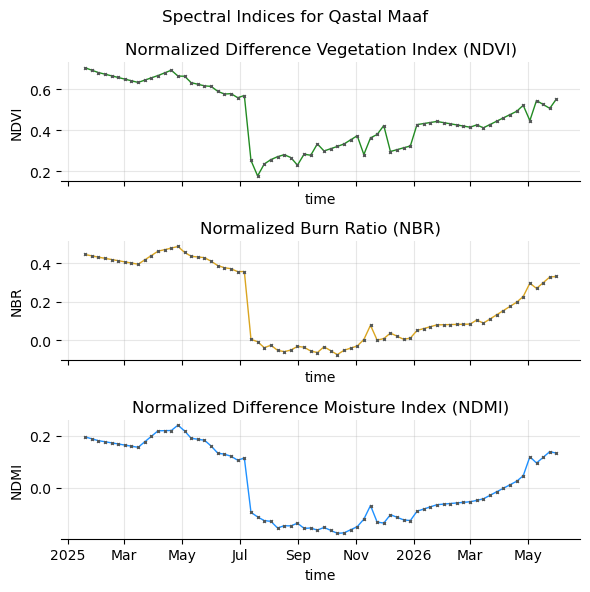

In [21]:
from plotting import plot_index_time_series

plot_index_time_series(qastal_data,
                       spec_index=['NDVI', 'NBR', 'NDMI'],
                       aoi_name=aoi_name)

We can clearly see from the indices time series that there is a significant change that took place in the summer of 2025, which is consistent with the timing of the wildfire event that we know happened in that area. The NDVI shows a sharp decline during that period, indicating a loss of vegetation health and vigor. We can see this pattern being echoed in the NBR and NDMI indicating a significant change in vegetation structure and moisture content consistent with burn severity.
A gradual recovery in the indices after the fire event seems to be occurring as well in 2026, although still not totally back to pre-fire levels which suggests that the ecosystem might have not fully recovered yet.

## Quantifying the Burn 

There is a lot more that can be done with this dataset to further analyze the burn severity and monitor the post-fire recovery. Let's start by looking at images pre- and post-fire to visually assess the changes. 

We can look up dates from:
- Before the fire: May, 2025
- After the fire: August, 2025
- Current: May, 2026

Let's list available dates in those months to pick the best ones for the visualization and analysis:

In [22]:
before = qastal_data.sel(time=slice("2025-05-01", "2025-05-31"))
print(f"Dates before the fire: {before.time.values}")

after = qastal_data.sel(time=slice("2025-07-15", "2025-08-15"))
print(f"Dates after the fire: {after.time.values}")

now = qastal_data.sel(time=slice("2026-05-01", "2026-05-30"))
print(f"Current dates: {now.time.values}")

Dates before the fire: ['2025-05-04T00:00:00.000000000' '2025-05-11T00:00:00.000000000'
 '2025-05-18T00:00:00.000000000' '2025-05-25T00:00:00.000000000']
Dates after the fire: ['2025-07-20T00:00:00.000000000' '2025-07-27T00:00:00.000000000'
 '2025-08-03T00:00:00.000000000' '2025-08-10T00:00:00.000000000']
Current dates: ['2026-05-03T00:00:00.000000000' '2026-05-10T00:00:00.000000000'
 '2026-05-17T00:00:00.000000000' '2026-05-24T00:00:00.000000000']


This returns a list of dates. We can take the average or median or just pick one date. I inspected the images and picked the dates that do not have a lot of pixels masked by cloud cover.

In [23]:
pre_fire_date = before.time.values[0]
post_fire_date = after.time.values[2]
current_date = now.time.values[1]

Now it is time to have a look at the images for those dates. 

The script to visualizes the RGB composites is available on [GitHub](https://github.com/astroAycha/wildfire_impact_analysis/blob/b4d44701a65467d033f565b4d03fa2538e187297/plotting.py#L90)

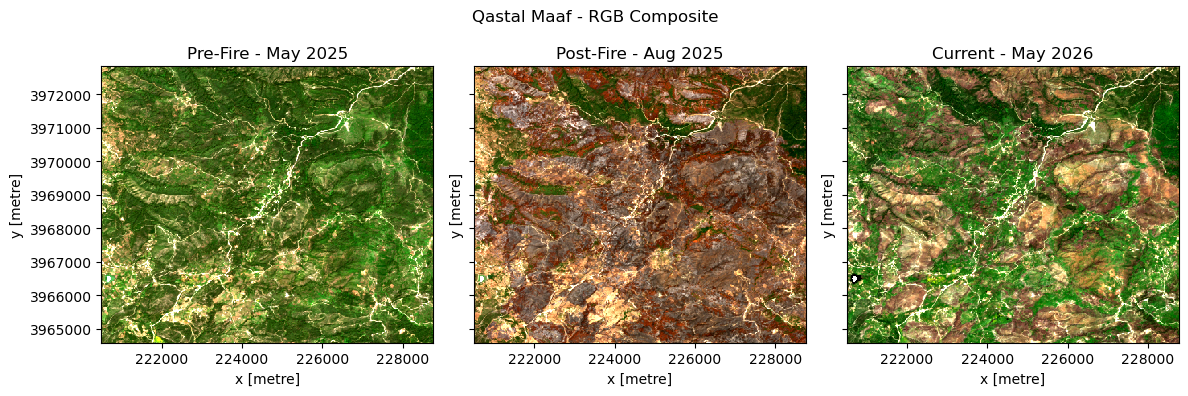

In [24]:
from plotting import plot_rgb_before_after_now

plot_rgb_before_after_now(input_dataset=qastal_data,
                    before_date=pre_fire_date,
                    after_date=post_fire_date,
                    now_date=current_date)

We can also examine the change in vegetation health before and after the fire event using spectral index maps and histograms. This can help us to quantify the extent of the damage and the recovery process. Below I plot the NDVI and NDMI maps and histograms for the three time points (before, after, and now) to visually assess the changes in vegetation health and moisture content. 

The script for the plotting function is available on [GitHub](https://github.com/astroAycha/wildfire_impact_analysis/blob/b4d44701a65467d033f565b4d03fa2538e187297/plotting.py#L128)

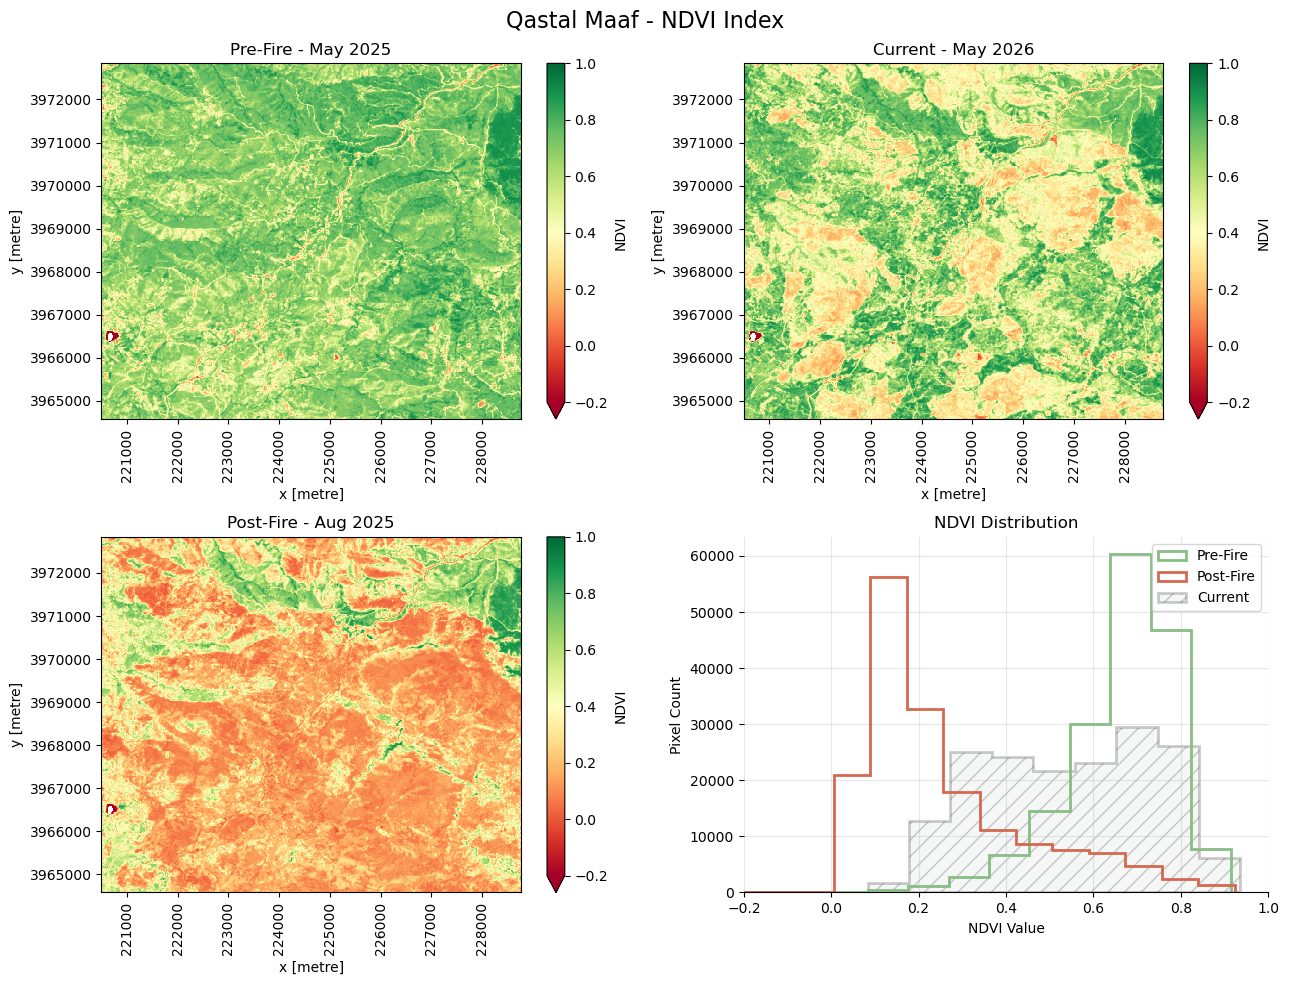

In [25]:
from plotting import plot_index_before_after_now

plot_index_before_after_now(input_dataset=qastal_data,
                            spec_index='NDVI',
                            cmap='RdYlGn',
                            before_date=pre_fire_date,
                            after_date=post_fire_date,
                            now_date=current_date,
                            range_min=-.2,
                            range_max=1)

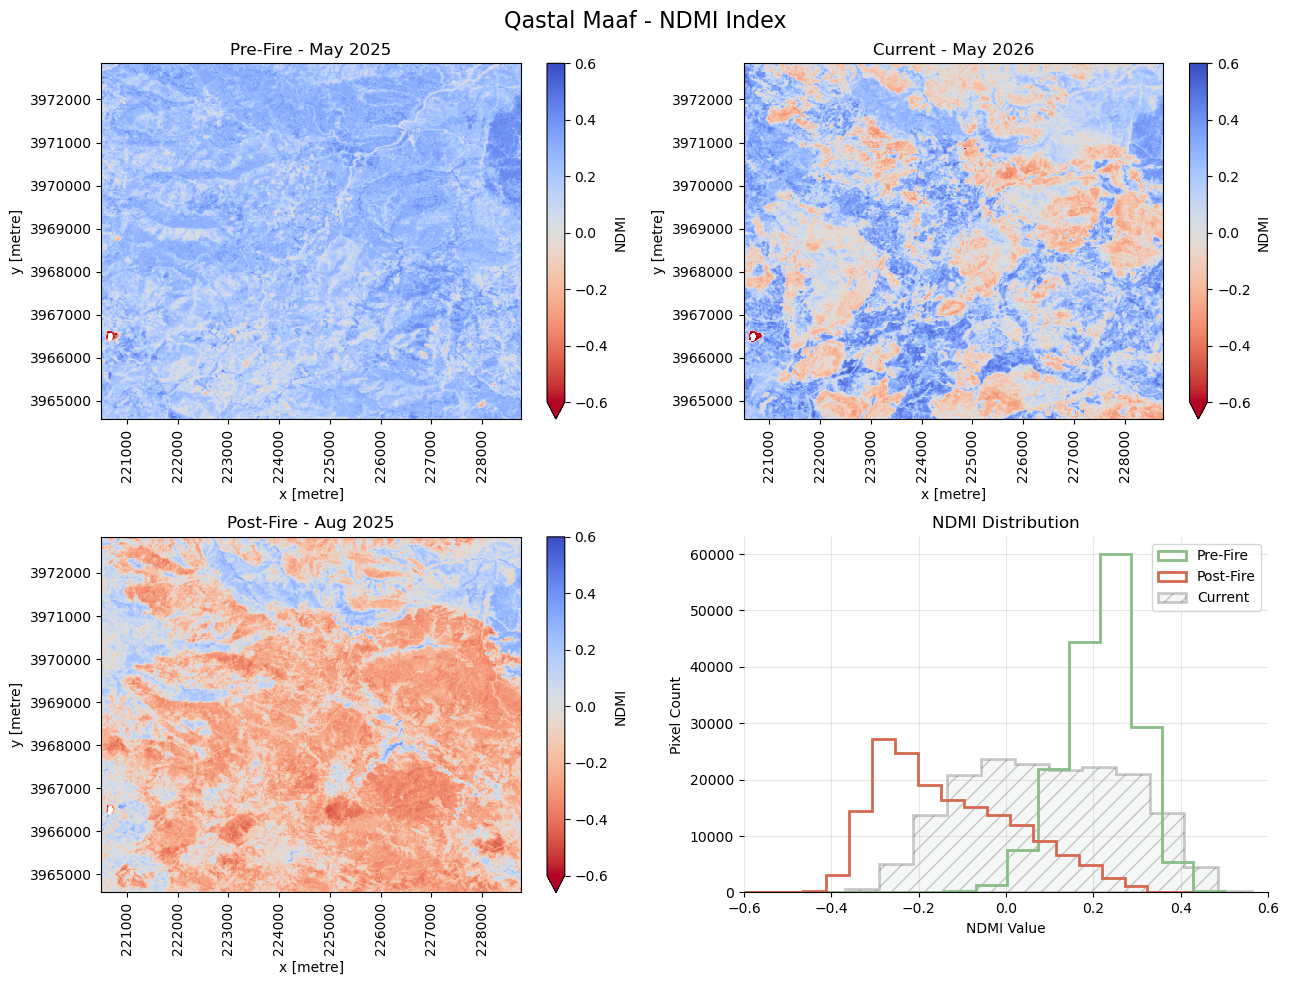

In [26]:
# plot changes in the NDMI index
plot_index_before_after_now(input_dataset=qastal_data,
                            spec_index='NDMI',
                            cmap='coolwarm_r',
                            before_date=pre_fire_date,
                            after_date=post_fire_date,
                            now_date=current_date,
                            range_min=-.6,
                            range_max=.6)

### Change in the Normalized Burn Ratio (dNBR)

Another interesting quantity that can help us further estimate the burn severity is the change in the NBR index before and after the fire event. The NBR is commonly used to assess burn severity, as it captures the difference in reflectance between the near-infrared and shortwave infrared bands, which is sensitive to changes in vegetation structure and moisture content. We can calculate the change in NBR (dNBR) by subtracting the post-fire NBR from the pre-fire NBR. Higher dNBR values indicate greater vegetation loss and soil char, i.e., higher burn severity. This can help us to quantify the extent of the damage and classify burn severity.

In [27]:
# calculate the change in the NBR index before and after the fire event
dnbr = (before.NBR.sel(time=pre_fire_date, drop=True).astype(float) - 
        after.NBR.sel(time=post_fire_date, drop=True).astype(float))

dnbr.name = "dNBR"

Let's visualize the dNBR to assess burn severity (code available on [GitHub](https://github.com/astroAycha/wildfire_impact_analysis/blob/8c6ce104a70db7aa355a3912d88ac703b0c4de54/plotting.py#L234))

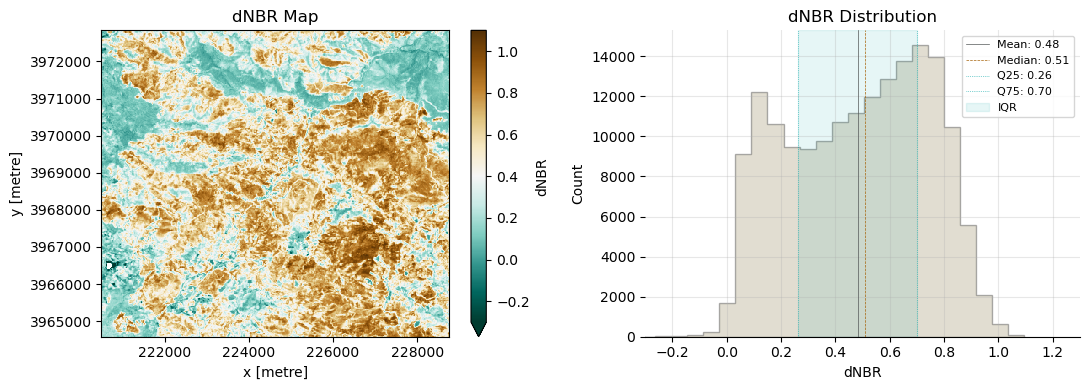

In [28]:
from plotting import plot_dnbr

plot_dnbr(dnbr)

Estimating burn severity is not a straightforward task and multiple factors need to be considered, such as the type of vegetation, the intensity of the fire, and the pre-fire conditions. The dNBR can provide a useful estimate of burn severity, but it is important to interpret the results in the context of the specific ecosystem and fire event being analyzed. Additionally, it is often helpful to combine dNBR with other indices and field observations to get a more comprehensive understanding of burn severity and its impacts on the ecosystem.

For this exploratory exercise, we will use a simple thresholding approach to classify the burn severity into two classes using the value of the 25th percentile: unburned (dNBR < 0.26) and burned (dNBR >= 0.26).

In [29]:
import xarray as xr

burn_threshold = 0.26  # using the 25th percentile dNBR value

# Classify burn severity based on the dNBR values using a simple thresholding approach
burn_class = xr.where(dnbr >= burn_threshold, 1, 0).where(dnbr.notnull())

burn_class.name = "Burn Class"

The result is a `xarray.DataArray` with binary values indicating burned and unburned areas, which can be further analyzed or visualized to assess the spatial extent of the burn severity.

In [30]:
burn_class

<xarray.DataArray 'Burn Class' (y: 413, x: 413)> Size: 1MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.]], shape=(413, 413))
Coordinates:
  * y            (y) float64 3kB 3.973e+06 3.973e+06 ... 3.965e+06 3.965e+06
  * x            (x) float64 3kB 2.205e+05 2.205e+05 ... 2.287e+05 2.288e+05
    spatial_ref  int32 4B 32637

In [ ]:
# we can save this for further analysis or visualization in GIS software
burn_class.rio.to_raster("burn_class.tif",
                            driver="COG",
                            compress="deflate",)

Let's use this classification `DataArray` to calculate the burned area and the percentage of the AOI that was burned:

In [31]:
# the pixel size we used when loading the data was 20m
pixel_size_m = 20 
pixel_area_km2 = (pixel_size_m / 1000) ** 2

burned_pixels   = int((burn_class == 1).sum())
unburned_pixels = int((burn_class == 0).sum())
total_pixels    = int(burn_class.notnull().sum())

burned_km2   = burned_pixels * pixel_area_km2
unburned_km2 = unburned_pixels * pixel_area_km2
total_km2    = total_pixels * pixel_area_km2

print(f"Burn Area Estimates - using dNBR threshold of {burn_threshold}")
print("For the entire AOI")
print("=" * 45)
print(f"{'Unburned':<30} {unburned_km2:>8.2f} km²")
print(f"{'Burned':<30} {burned_km2:>8.2f} km²")
print("-" * 45)
print(f"{'Total Area':<30} {total_km2:>8.2f} km²")
print(f"{'% Burned':<30} {100 * burned_km2 / total_km2:>7.1f}%")

Burn Area Estimates - using dNBR threshold of 0.26
For the entire AOI
Unburned                          16.92 km²
Burned                            51.29 km²
---------------------------------------------
Total Area                        68.21 km²
% Burned                          75.2%


The area that was burned is 68.21 km2 which is slightly more than 75% of our AOI. This is representing values that are higher than the 25th percentile dNBR value which means the burn severity is likely moderate to high. Other areas that are classified here as unburned could potentially include areas that were affected by the fire but for a lesser degree of severity. It is important to iterate that more robust estimation of burn severity require a more rigorous approach that often include field measurements (or claculations based on calibrated models based on field data) to establish more accurate thresholds for burn severity classification.

## Validating the Burn Impact Estimates

To validate the burn estimates we just calculated, we compare our results with those from the [Copernicus Emergency Management Service (EMS)](https://mapping.emergency.copernicus.eu/activations/EMSR811/) to see if our estimates align with their assessments of the severity of the fire event. EMS produced a detailed damage assessment for this wildfire event.

To get the data you can simply follow the link and download the zip file containing the damage assessment for the wildfire event. We can also use the API to access the data. There is little difference between the two approaches in this case since we are only downloading one compressed file to use for validation. 

I will go with the API for reproducibility and so I can continue to work in the notebook without having to switch to the web interface.

In [186]:
import requests
import pandas as pd

url = "https://rapidmapping.emergency.copernicus.eu/backend/dashboard-api/public-activations/?code=EMSR811"

data = requests.get(url).json()
print(f"{data.keys()}")
print(f"Count: {data['count']}")

dict_keys(['count', 'next', 'previous', 'results'])
Count: 1


In [187]:
# take a peek at the data structure

activation = data["results"][0]

print(activation.keys())

print("Event:", activation["eventTime"])
print("Activation:", activation["activationTime"])
print('country', activation["countries"])
print('extent', activation["extent"])
print('stats', activation["stats"])

dict_keys(['code', 'name', 'reason', 'category', 'subCategory', 'sensitive', 'reportLink', 'activator', 'eventTime', 'activationTime', 'closed', 'gdacsId', 'continent', 'countries', 'aois', 'centroid', 'infobulletins', 'stats', 'charterNumber', 'charterUrl', 'extent', 'aws_bucket', 'productsPath', 'relatedevents'])
Event: 2025-07-03T12:00:00
Activation: 2025-07-07T16:28:00
country [{'name': 'Syria'}]
extent POLYGON ((35.876487 35.696648, 35.876487 35.898683, 36.065869 35.898683, 36.065869 35.696648, 35.876487 35.696648))
stats {'max_extent': 10014.2, 'Built-up [ha]': 904, 'Population [No.]': 250, 'Event Extent [ha]': 10014.2}


If you would like to use the API you can find the script [here](https://github.com/astroAycha/wildfire_impact_analysis/blob/main/get_validation_data.py)

In [45]:
# # this downloads the data and extracts it to a folder called "ems_data"
from get_validation_data import get_ems_data

get_ems_data(overwrite=True)

Acquisition time: 2025-07-24T08:20:00
Sensor: GeoEye-1


Now, we can read the shape file containing the fire damage data and visualize the results to compare with our burn severity estimates:

In [52]:
import geopandas as gpd

file_path = "./ems_data/EMSR811_AOI01_GRA_PRODUCT_observedEventA_v1.shp"

burn_perimeter = gpd.read_file(file_path)

print(f">>> burn perimeter CRS: {burn_perimeter.crs}")
print(f">>> Estimated UTM CRS: {burn_perimeter.estimate_utm_crs()}")
print(f">>> burn perimeter shape: {burn_perimeter.shape}")
burn_perimeter.head(n=2)

>>> burn perimeter CRS: EPSG:4326
>>> Estimated UTM CRS: EPSG:32636
>>> burn perimeter shape: (1882, 7)


,event_type,obj_desc,det_method,notation,dmg_src_id,area,geometry
0,8-Wildfire,Forest Fire,Semi-automatic extraction,Burnt area,13,0.106293,"POLYGON ((35.98904 35.71217, 35.98902 35.71217..."
1,8-Wildfire,Forest Fire,Semi-automatic extraction,Burnt area,13,0.053946,"POLYGON ((35.99033 35.71235, 35.99035 35.71235..."


Since our AOI does not fully overlap with the EMS AOI, we can clip the burn perimeter to our AOI to make a more direct comparison with our burn severity estimates:

In [53]:
burn_perimeter_clipped = gpd.clip(burn_perimeter, aoi_gdf) # 4326, for use with Folium
burn_perimeter_clipped_utm = burn_perimeter_clipped.to_crs("EPSG:32637")

print(f">>> Clipped burn perimeter shape: {burn_perimeter_clipped_utm.shape}")

>>> Clipped burn perimeter shape: (419, 7)


Let's now take a look at the burn perimeter data on the map. The map was generated using the script [here](https://github.com/astroAycha/wildfire_impact_analysis/blob/c1187c208360b2f92e42750ff36a1c0bf2ff7ca2/plotting.py#L346)

In [136]:
from IPython.display import IFrame
map_path = "./maps/burn_perimeter_map.html"
IFrame(map_path, width="100%", height=500)

### Burn Area Comparison

Let's now compare the burn area from our estimates with the burn area from the EMS data. We can calculate the total burned area from the EMS data and compare it with our estimates to see how well they align.

For the EMS data, we can directly calculate the total burned area from the burn perimeter polygons, which represent the spatial extent of the burned area as assessed by EMS. We can sum up the areas of these polygons to get the total burned area according to EMS.

In [64]:
print(f"Total burned area for the AOI from EMS data:")
print(f"{burn_perimeter_clipped_utm.area.sum() / 1e6:.2f} km²")

Total burned area for the AOI from EMS data:
43.82 km²


The area of the burned land based on the dNBR cutoff can be calculated from the values of the burn classification `DataArray` that we created earlier. By summing the number of pixels classified as burned and multiplying by the area of each pixel, we can estimate the total burned area in square kilometers. This allows us to quantitatively compare our burn area estimates with those of the EMS assessment and evaluate the accuracy of our results.

In [77]:
import rioxarray
    
burn_quant = []

# loop through each burn perimeter polygon and calculate the number of 
# burned and unburned pixels within it
for idx, row in burn_perimeter_clipped_utm.iterrows():
    clipped = burn_class.rio.clip(
        [row.geometry],
        burn_perimeter_clipped_utm.crs,
        drop=True,
        all_touched=True
    )
    n_burned = int((clipped == 1).sum())
    n_unburned = int((clipped == 0).sum())
    burn_quant.append({
        "burned_pixels": n_burned,
        "unburned_pixels": n_unburned,
        "burned_area_km2": n_burned * pixel_area_km2,
        "unburned_area_km2": n_unburned * pixel_area_km2
    })

# convert the burn quantification results into a DataFrame for easier analysis
burn_quant_df = pd.DataFrame(burn_quant)

print("Burn impact within the EMS burn perimeter based on the dNBR classification")
(burn_quant_df
 .sum()
 .to_frame()
 .T
 .style
 .format("{:.2f}")
 )

Burn impact within the EMS burn perimeter based on the dNBR classification


,burned_pixels,unburned_pixels,burned_area_km2,unburned_area_km2
0,118018.00,9021.00,47.21,3.61


### Classification Metrics

For a more detailed comparison between our burn classification (using the dNBR cutoff) and the EMS burn perimeter data, we can rasterize the EMS burn polygons so we can see where exactly our burn classification agrees or disagrees with the EMS assessment on a pixel-by-pixel basis. This will allow us to calculate classification metrics such as precision, recall, F1-score, and Jaccard index to quantitatively assess the agreement between our burn classification and the EMS burn perimeter.

In [ ]:
from rasterio.features import rasterize
from shapely.geometry import mapping
import numpy as np

# clip the burn classification raster to the AOI extent
burn_class_clipped = burn_class.rio.clip(aoi_utm.geometry, all_touched=False)

# get the dimensions of the clipped burn classification raster
height, width = burn_class_clipped.shape

# rasterize's shapes argument expects an iterable of (geometry, value) pairs, 
# where the geometry is in GeoJSON-like format (hence the use of `mapping`)
# and the value is what you want to burn into the raster: 1 for burned areas 

shapes = [(mapping(geom), 1) for geom in burn_perimeter_clipped_utm.geometry]

# rasterize the burn perimeter polygons to create a reference raster 
burned_ref = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=burn_class_clipped.rio.transform(),
    fill=0, # pixels outside polygon = 0
    all_touched=False, # only burn pixels whose center is within the polygon
    dtype=np.uint8
)

We can now evaluate the agreement between our burn classification and the EMS burn perimeter by calculating classification metrics such as the number of pixels classified as burned and unburned within the EMS burn perimeter, and comparing these values to the total area of the burn perimeter. This will give us an indication of how well our burn severity estimates align with the EMS assessment and help us to understand any discrepancies between the two datasets.

Using `sklearn.metrics` we can calculate the confusion matrix and other classification metrics to quantitatively assess the agreement between our burn classification and the EMS burn perimeter. This will allow us to identify any areas where there may be discrepancies between the two datasets.

We can also look at the Intersection over Union (IoU) metric. The IoU is calculated as the area of overlap between the predicted burn area and the reference burn area divided by the area of their union. An IoU value of 1 indicates perfect agreement, while a value of 0 indicates no overlap. For this we use  `sklearn.metrics.jaccard_score`, which calculates the Jaccard index (IoU) for binary classifications.

In [82]:
from sklearn.metrics import classification_report
from sklearn.metrics import jaccard_score

# Ground truth
y_true = burned_ref.flatten()

# Prediction
y_pred = (burn_class_clipped.values == 1).astype(int).flatten()

# Remove invalid pixels
valid = ~np.isnan(burn_class_clipped.values).flatten()
y_true = y_true[valid]
y_pred = y_pred[valid]

# Intersection over Union (IoU) or Jaccard Index
iou = jaccard_score(y_true, y_pred)

# print the classification report
print("Classification Report:")
print("=" * 30)

print(f"IoU = {iou:.3f}")
print("=" * 30)

print(classification_report(
    y_true,
    y_pred,
    target_names=["Unburned", "Burned"]
))

Classification Report:
IoU = 0.858
              precision    recall  f1-score   support

    Unburned       0.93      0.70      0.80     50340
      Burned       0.88      0.97      0.92    109504

    accuracy                           0.89    159844
   macro avg       0.90      0.84      0.86    159844
weighted avg       0.89      0.89      0.88    159844



We can also visualize the classification results using the confusion matrix.

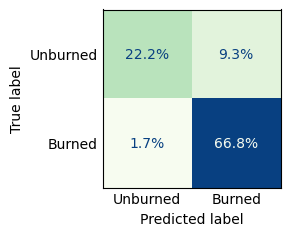

In [120]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 3))

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum()  # each cell as fraction of all pixels

ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["Unburned", "Burned"]
).plot(ax=ax, cmap="GnBu", values_format=".1%", colorbar=False)

ax.tick_params(length=0)
plt.tight_layout()
plt.show()

What those results show is that overall our burn classification based on the dNBR cutoff is atcheiving a good level of agreement with the EMS burn perimeter, as indicated by the IoU score of 85.8%. It also has high recall and precision for the burned and unburned areas. The score drops in the recall for unburned areas which suggests that there are some areas that were classified as burned in our estimates but are not included in the EMS burn perimeter. 
I suspect some variations in the classification are simply due to the changing nature of the fire event and the fact that the burn perimeter is not a static boundary but rather a dynamic one that can change over time as the fire spreads and evolves. Additionally, there may be some discrepancies in the spatial resolution and accuracy of the satellite data used for our burn classification compared to the data used by EMS for their assessment, which could also contribute to differences in the classification results. Overall, while there is good agreement between our burn classification and the EMS burn perimeter, it is important to consider these factors when interpreting the results and understanding any discrepancies that may arise.

### On the Map

On more thing we can do is to plot the predictions on the map so we can visually inspect the spatial distribution of burned and unburned areas.

In [ ]:
from plotting import plot_comparison_map
plot_comparison_map(burned_ref, burn_class_clipped, burn_perimeter_clipped, aoi_utm)

In [135]:
comparison_map_path = "./maps/comparison_map.html"
IFrame(comparison_map_path, width="100%", height=500)

## Summary & Conclusion

In this walkthrough, we demonstrated how to use satellite imagery to monitor wildfire impacts by calculating spectral indices and analyzing changes over time. We focused on a case study of a wildfire event in Northwest Syria, where we analyzed changes in vegetation health and moisture content before and after the fire. We used Sentinel-2 data to calculate indices such as NDVI, NBR, and NDWI, and we assessed burn severity using the change in NBR (dNBR). Finally, we validated our results by comparing them with the Copernicus Emergency Management Service (EMS) assessment for the same area and time period. This workflow can be applied to other regions and time periods to monitor environmental changes and assess the impacts of wildfires on ecosystems.

| Class        | Precision | Recall | F1-Score | Support |
|--------------|-----------|--------|----------|---------|
| Unburned     | 0.93      | 0.70   | 0.80     | 50,340  |
| Burned       | 0.88      | 0.97   | 0.92     | 109,504 |
| **Accuracy** | &nbsp;    | &nbsp; | **0.89** | 159,844 |
| Macro Avg    | 0.90      | 0.84   | 0.86     | 159,844 |
| Weighted Avg | 0.89      | 0.89   | 0.88     | 159,844 |


Other metrics also include:

| Metric                       | Value      |
|------------------------------|------------|
| IoU (Jaccard Score)          | 0.858      |
| Burned Area (EMS Reference)  | 43.82 km2  |
| Burned Area (True Positives)  | 42.70 km2  |

Here is a quick summary of the key steps in the workflow:
1. Define the area of interest (AOI) and time period for analysis.
2. Retrieve fire data from FIRMS to identify the timing of the wildfire event.
3. Use the STAC API to search for and load Sentinel-2 imagery for the AOI and time period of interest.
4. Pre-process the imagery by applying cloud masks using the SCL band to remove cloud-contaminated pixels.
5. Calculate spectral indices (NDVI, NBR, NDWI) to assess vegetation health and moisture content.
6. Analyze the time series of spectral indices to identify changes before and after the fire event.
7. Calculate the change in NBR (dNBR) to estimate burn severity.
8. Validate the burn severity estimates by comparing them with the Copernicus EMS assessment for the same area and time period.

## Limitations

- dNBR is sensitive to image selection.
- Burn severity thresholds are ecosystem dependent.
- No field observations were available.
- Cloud contamination may affect some pixels.
- EMS products are themselves derived products, not ground truth.

## Useful Resources
- [Earth Search API](https://element84.com/earth-search)
- [Sentinel-2 L2A data on AWS](https://registry.opendata.aws/sentinel-2/)
- [Sentinel-2 Spectral Indices](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/indexdb/)
- [STAC API Specification](https://stacspec.org/)
- [FIRMS API](https://firms.modaps.eosdis.nasa.gov/api/)
- [Wildfire in Latakia, Syria, Copernicus Emergency Management Service](https://mapping.emergency.copernicus.eu/activations/EMSR811/)


In [138]:
print(f"Last updated: {datetime.datetime.now().strftime('%Y-%m-%d')}")

Last updated: 2026-06-03
